# MERF + Support Vector Regression

Mixed-effects models with **SVR** fixed effects. Evaluation mirrors `SVM.ipynb`.

**Exports:** `results/logs/merf_svr_results.xlsx`, `results/logs/merf_svr/*.csv`, merged into `svm_results.xlsx` for figures.

Run all cells in order (top to bottom).


In [37]:
%pip install -q merf aif360 shap lime openpyxl



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports and dependencies


In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, wilcoxon
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from merf.merf import MERF

try:
    from aif360.datasets import BinaryLabelDataset
    from aif360.metrics import BinaryLabelDatasetMetric
except ImportError:
    BinaryLabelDataset = None
    BinaryLabelDatasetMetric = None



## Paths and results store


In [39]:
BASE = Path(r"C:/Users/janku/Documents/KCL/Research Project/Research Project")
LOGS_DIR = BASE / "results/logs"
EXCEL_EXPORT_PATH = LOGS_DIR / "merf_svr_results.xlsx"
SVM_EXCEL_EXPORT_PATH = LOGS_DIR / "svm_results.xlsx"
CSV_EXPORT_DIR = LOGS_DIR / "merf_svr"
MERF_MODEL_TAG = "MERF-SVR"

# Same sheet keys as SVM.ipynb / figures_fainres.ipynb
RESULTS_STORE = {
    "split_info": [],
    "best_params": [],
    "train_test_balance": [],
    "train_test_distribution": [],
    "cv_folds": [],
    "cv_balance": [],
    "statistical_tests": [],
    "cv_summary": [],
    "test_summary": [],
    "subgroup_gender": [],
    "subgroup_age": [],
    "subgroup_gender_age": [],
    "fairness": [],
    "wilcoxon": [],
    "confusion_matrices": [],
}

def reset_results_store():
    for key in RESULTS_STORE:
        RESULTS_STORE[key] = []


def record_table(sheet_key, model_name, df):
    if df is None or len(df) == 0:
        return
    out = df.copy() if not isinstance(df, pd.Series) else df.to_frame().T
    if "model" not in out.columns:
        out.insert(0, "model", model_name)
    RESULTS_STORE.setdefault(sheet_key, []).append(out)


def record_confusion_matrix(model_name, cm, matrix_name):
    cm = np.asarray(cm)
    rows = []
    for i, true_lab in enumerate(["control_0", "depressed_1"]):
        for j, pred_lab in enumerate(["control_0", "depressed_1"]):
            rows.append({
                "model": model_name,
                "matrix": matrix_name,
                "true_label": true_lab,
                "pred_label": pred_lab,
                "count": int(cm[i, j]),
            })
    RESULTS_STORE.setdefault("confusion_matrices", []).append(pd.DataFrame(rows))


def record_standard_model_outputs(model_name, **kwargs):
    mapping = {
        "split_info": "split_info",
        "best_params": "best_params",
        "train_test_balance": "train_test_balance",
        "train_test_distribution": "train_test_distribution",
        "cv_folds": "cv_folds",
        "cv_balance": "cv_balance",
        "statistical_tests": "statistical_tests",
        "cv_summary": "cv_summary",
        "test_summary": "test_summary",
        "wilcoxon": "wilcoxon",
        "confusion_matrices": None,
    }
    for key, sheet in mapping.items():
        val = kwargs.get(key)
        if val is None:
            continue
        if key == "confusion_matrices":
            for matrix_name, cm in val.items():
                record_confusion_matrix(model_name, cm, matrix_name)
        elif key == "wilcoxon":
            for test_name, p_value in val.items():
                record_table("wilcoxon", model_name, pd.DataFrame([{"test_name": test_name, "p_value": p_value}]))
        elif key == "split_info":
            record_table(sheet, model_name, pd.DataFrame([val]))
        elif key == "best_params":
            record_table(sheet, model_name, pd.DataFrame([val]))
        elif key == "train_test_distribution":
            dist = val.reset_index().rename(columns={"index": "label"})
            record_table(sheet, model_name, dist)
        else:
            record_table(sheet, model_name, val)


def _train_test_distribution_table(y_bin_train, y_bin_test):
    return pd.DataFrame(
        {
            "train": [int((y_bin_train == 0).sum()), int((y_bin_train == 1).sum())],
            "test": [int((y_bin_test == 0).sum()), int((y_bin_test == 1).sum())],
        },
        index=["control", "depressed"],
    )



## Export to Excel / CSV


In [40]:
def build_results_tables():
    """Concatenate in-memory RESULTS_STORE frames per sheet."""
    tables = {}
    for sheet_key, frames in RESULTS_STORE.items():
        if frames:
            tables[sheet_key] = pd.concat(frames, ignore_index=True)
    return tables


def _write_tables_to_excel(tables, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        wrote = False
        for sheet_key, df in tables.items():
            df.to_excel(writer, sheet_name=sheet_key[:31], index=False)
            wrote = True
        if not wrote:
            pd.DataFrame({"message": ["No results recorded."]}).to_excel(writer, sheet_name="info", index=False)
    return path


def export_results_to_csv(tables=None, csv_dir=CSV_EXPORT_DIR):
    """One CSV per sheet under results/logs/merf_svr/ (same schema as SVM Excel sheets)."""
    tables = tables or build_results_tables()
    csv_dir = Path(csv_dir)
    csv_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for sheet_key, df in tables.items():
        out = csv_dir / f"{sheet_key}.csv"
        df.to_csv(out, index=False)
        paths.append(out)
    print(f"\nCSV exports ({len(paths)} files) under: {csv_dir.resolve()}")
    return paths


def merge_tables_into_workbook(merf_tables, target_path=SVM_EXCEL_EXPORT_PATH, model_tag=MERF_MODEL_TAG):
    """Append MERF rows into the SVM results workbook for figures_fainres.ipynb."""
    target_path = Path(target_path)
    merged = {}

    if target_path.exists():
        xl = pd.ExcelFile(target_path)
        existing_sheets = xl.sheet_names
    else:
        existing_sheets = []

    all_sheets = set(existing_sheets) | set(merf_tables.keys())
    for sheet in all_sheets:
        parts = []
        if sheet in existing_sheets:
            old = pd.read_excel(target_path, sheet_name=sheet)
            if "model" in old.columns:
                old = old[~old["model"].astype(str).str.contains(model_tag, na=False)]
            parts.append(old)
        if sheet in merf_tables:
            parts.append(merf_tables[sheet])
        if parts:
            merged[sheet] = pd.concat(parts, ignore_index=True)

    if not merged:
        merged = merf_tables

    _write_tables_to_excel(merged, target_path)
    print(f"\nMerged MERF results into: {target_path.resolve()}")
    return target_path


def export_results(
    excel_path=EXCEL_EXPORT_PATH,
    export_csv=True,
    merge_into_svm_workbook=True,
    svm_workbook_path=SVM_EXCEL_EXPORT_PATH,
):
    """
    Save MERF-SVR results like SVM.ipynb:
    - multi-sheet Excel in results/logs/
    - per-sheet CSVs in results/logs/merf_svr/
    - optionally merge into svm_results.xlsx for figure generation
    """
    tables = build_results_tables()
    if not tables:
        print("No results to export.")
        return None

    merf_xlsx = _write_tables_to_excel(tables, excel_path)
    print(f"Excel workbook saved to: {merf_xlsx.resolve()}")

    if export_csv:
        export_results_to_csv(tables)

    if merge_into_svm_workbook:
        merge_tables_into_workbook(tables, target_path=svm_workbook_path)

    return merf_xlsx


def export_results_to_excel(path=EXCEL_EXPORT_PATH, export_csv=True, merge_into_svm_workbook=True):
    """Backward-compatible alias for export_results."""
    return export_results(
        excel_path=path,
        export_csv=export_csv,
        merge_into_svm_workbook=merge_into_svm_workbook,
    )



## Metrics, confusion matrices, subgroups, fairness


In [41]:
def confusion_matrix_for_display(y_true, y_pred, title):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["control (0)", "depressed (1)"]).plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    return cm

def _safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def evaluate_by_group(y_true, y_pred, y_score, sensitive_feature):
    eval_df = pd.DataFrame({
        "y_true": np.asarray(y_true).astype(int),
        "y_pred": np.asarray(y_pred).astype(int),
        "y_score": np.asarray(y_score, dtype=float),
        "group": pd.Series(sensitive_feature).reset_index(drop=True),
    }).dropna(subset=["group"])
    rows = []
    for group_value, group_df in eval_df.groupby("group", dropna=True):
        rows.append({
            "group": group_value,
            "n": len(group_df),
            "n_depressed": int(group_df["y_true"].sum()),
            "n_control": int((group_df["y_true"] == 0).sum()),
            "accuracy": accuracy_score(group_df["y_true"], group_df["y_pred"]),
            "f1": f1_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "roc_auc": _safe_auc(group_df["y_true"], group_df["y_score"]),
        })
    return pd.DataFrame(rows)


def _gender_from_file_stem(file_stem):
    extracted = pd.Series(file_stem).astype(str).str.extract(r"^[0-9]+_[A-Z]?([FM])\d+", expand=False)
    return extracted.map({"F": "female", "M": "male"})


def _age_from_file_stem(file_stem):
    return pd.to_numeric(
        pd.Series(file_stem).astype(str).str.extract(r"^[0-9]+_[A-Z]?[FM](\d+)", expand=False),
        errors="coerce",
    )


def _format_gender(gender_values):
    gender = pd.Series(gender_values).reset_index(drop=True)
    if pd.api.types.is_numeric_dtype(gender):
        return "gender_" + gender.astype("Int64").astype(str)
    normalized = gender.astype(str).str.strip().str.lower()
    return normalized.replace({"f": "female", "female": "female", "m": "male", "male": "male"})


def make_subgroup_frame(df_rows):
    rows = df_rows.reset_index(drop=True)
    subgroup_df = pd.DataFrame(index=rows.index)
    if "Gender" in rows.columns:
        subgroup_df["gender"] = _format_gender(rows["Gender"])
    elif "file_stem" in rows.columns:
        subgroup_df["gender"] = _gender_from_file_stem(rows["file_stem"])
    if "Age" in rows.columns:
        age = pd.to_numeric(rows["Age"], errors="coerce")
    elif "file_stem" in rows.columns:
        age = _age_from_file_stem(rows["file_stem"])
    else:
        age = pd.Series(np.nan, index=rows.index)
    subgroup_df["age_group"] = pd.cut(age, bins=[-np.inf, 35, 55, np.inf], labels=["young", "middle", "older"]).astype("object")
    if {"gender", "age_group"}.issubset(subgroup_df.columns):
        subgroup_df["gender_age_group"] = (
            subgroup_df["age_group"].astype(str) + " " + subgroup_df["gender"].astype(str)
        )
        subgroup_df.loc[subgroup_df["gender"].isna() | subgroup_df["age_group"].isna(), "gender_age_group"] = np.nan
    return subgroup_df


def _gender_binary_code(df_rows):
    rows = df_rows.reset_index(drop=True)
    if "Gender" in rows.columns:
        return pd.to_numeric(rows["Gender"], errors="coerce")
    if "file_stem" in rows.columns:
        return _gender_from_file_stem(rows["file_stem"]).map({"female": 0, "male": 1})
    return pd.Series(np.nan, index=rows.index)


def print_aif360_fairness_metrics(model_name, y_pred, df_test_rows):
    if BinaryLabelDataset is None:
        print(f"\n{model_name} AIF360 skipped (package not installed)")
        return
    gender = _gender_binary_code(df_test_rows)
    valid = gender.notna()
    if valid.sum() < 2 or len(np.unique(gender[valid])) < 2:
        print(f"\n{model_name} AIF360 fairness metrics: insufficient gender groups")
        return
    fairness_df = pd.DataFrame({
        "gender": gender[valid].astype(int).to_numpy(),
        "depressed": np.asarray(y_pred, dtype=int).reshape(-1, 1)[valid.to_numpy()].ravel(),
        "dummy": 1,
    })
    dataset = BinaryLabelDataset(
        df=fairness_df,
        label_names=["depressed"],
        protected_attribute_names=["gender"],
        favorable_label=1,
        unfavorable_label=0,
    )
    metric = BinaryLabelDatasetMetric(
        dataset,
        privileged_groups=[{"gender": 1}],
        unprivileged_groups=[{"gender": 0}],
    )
    out = pd.DataFrame([{
        "disparate_impact": float(metric.disparate_impact()),
        "statistical_parity_difference": float(metric.statistical_parity_difference()),
    }])
    record_table("fairness", model_name, out)
    print(f"\n{model_name} AIF360 fairness metrics (held-out predictions):")
    print(out.to_string(index=False))


def print_subgroup_results(model_name, y_true, y_pred, y_score, subgroup_df, df_test_rows):
    sheet_map = {"gender": "subgroup_gender", "age_group": "subgroup_age", "gender_age_group": "subgroup_gender_age"}
    for column, label in [("gender", "Gender"), ("age_group", "Age group"), ("gender_age_group", "Gender x age group")]:
        if column not in subgroup_df.columns:
            print(f"\n{model_name} {label} results: unavailable")
            continue
        results = evaluate_by_group(y_true, y_pred, y_score, subgroup_df[column])
        print(f"\n{model_name} {label} results:")
        print(results)
        record_table(sheet_map[column], model_name, results)
    print_aif360_fairness_metrics(model_name, y_pred, df_test_rows)



## SHAP / LIME and MERF fit helper


In [42]:
def run_shap_lime_explanations(model_name, model, X_train, X_test, feature_names, mode="regression"):
    try:
        import shap
        from lime.lime_tabular import LimeTabularExplainer
    except ImportError:
        print(f"\n{model_name} SHAP/LIME skipped (install shap and lime)")
        return
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    rng = np.random.default_rng(42)
    bg_idx = rng.choice(len(X_train), size=min(1000, len(X_train)), replace=False)
    test_idx = rng.choice(len(X_test), size=min(500, len(X_test)), replace=False)
    X_bg, X_shap = X_train[bg_idx], X_test[test_idx]
    print(f"\n{model_name} SHAP summary (n={len(X_shap)}):")
    try:
        explainer = shap.Explainer(model, X_bg)
        shap_values = explainer(X_shap)
        shap.summary_plot(shap_values, pd.DataFrame(X_shap, columns=feature_names), show=False)
        plt.tight_layout()
        plt.show()
        plt.close("all")
    except Exception as exc:
        print(f"  SHAP failed: {exc}")
    predict_fn = model.predict if mode == "regression" else model.predict_proba
    print(f"\n{model_name} LIME (2 instances):")
    try:
        lime_explainer = LimeTabularExplainer(X_bg, feature_names=list(feature_names), mode=mode, discretize_continuous=True)
        for i in range(min(2, len(X_test))):
            exp = lime_explainer.explain_instance(X_test[i], predict_fn, num_features=min(10, len(feature_names)))
            fig = exp.as_pyplot_figure()
            plt.tight_layout()
            plt.show()
            plt.close(fig)
    except Exception as exc:
        print(f"  LIME failed: {exc}")

def _bdi_threshold_from_train(y_train, y_bin_train, default=13.0):
    """Threshold between control/depressed BDI on training rows (midpoint)."""
    ctrl = y_train[y_bin_train == 0]
    dep = y_train[y_bin_train == 1]
    if len(ctrl) and len(dep):
        return float((np.max(ctrl) + np.min(dep)) / 2.0)
    return default


def _wilcoxon_paired(y_true, pred_a, pred_b):
    e1 = np.abs(np.asarray(y_true, dtype=float) - np.asarray(pred_a, dtype=float))
    e2 = np.abs(np.asarray(y_true, dtype=float) - np.asarray(pred_b, dtype=float))
    if len(e1) < 2 or np.allclose(e1, e2):
        return float("nan")
    return float(wilcoxon(e1, e2, zero_method="wilcox", mode="auto").pvalue)


def _as_cluster_series(clusters):
    return pd.Series(np.asarray(clusters).ravel(), name="cluster")


def _fit_merf_svr_predict(X_train, Z_train, clusters_train, y_train, X_test, Z_test, clusters_test, svr_params):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    Z_train_a = np.asarray(Z_train, dtype=float)
    Z_test_a = np.asarray(Z_test, dtype=float)
    clusters_train_s = _as_cluster_series(clusters_train)
    clusters_test_s = _as_cluster_series(clusters_test)
    svr = SVR(**svr_params)
    merf_model = MERF(fixed_effects_model=svr, max_iterations=20)
    merf_model.fit(X_train_s, Z_train_a, clusters_train_s, y_train)
    y_pred = merf_model.predict(X_test_s, Z_test_a, clusters_test_s)
    return y_pred, scaler, svr, merf_model




## RADAR MERF-SVR


In [43]:
def run_merf_svr_radar():
    model_name = "RADAR MERF-SVR"
    print("\n" + "=" * 80)
    print(f"MODEL SECTION: {model_name}")
    print("=" * 80 + "\n")

    dataset = BASE / "data/processed/radar_model_dataset_raw_features.csv"
    df = pd.read_csv(dataset)
    df["participant_id"] = df["participant_id"].astype(str).str.strip()

    x_candidates = [
        "Speaking_Rate", "Articulation_Rate", "Phonation_Ratio", "Pause_Rate", "Pause_Ratio",
        "mean_F0", "stdev_F0_Semitone", "HNR_dB", "Spectral_Slope", "Spectral_Tilt",
        "Cepstral_Peak_Prominence", "mean_F1_Loc", "std_F1_Loc", "mean_B1_Loc", "std_B1_Loc",
        "mean_F2_Loc", "std_F2_Loc", "mean_B2_Loc", "std_B2_Loc", "Spectral_Gravity", "Spectral_Std_Dev",
    ]
    z_features = [c for c in ["Age", "Gender", "Education_Years", "Height"] if c in df.columns]
    feature_cols = [c for c in x_candidates if c in df.columns]
    required = feature_cols + z_features + ["phq8_score", "participant_id"]
    df = df.dropna(subset=required).copy()

    df["depressed"] = (df["phq8_score"] >= 10).astype(int)
    X = df[feature_cols].values
    y = df["phq8_score"].values
    y_bin = df["depressed"].values
    groups = df["participant_id"].values
    Z = df[z_features].copy()

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    y_bin_train, y_bin_test = y_bin[train_idx], y_bin[test_idx]
    Z_train, Z_test = Z.iloc[train_idx], Z.iloc[test_idx]
    groups_train, groups_test = groups[train_idx], groups[test_idx]

    print("Train rows:", len(train_idx), "| Test rows:", len(test_idx))
    print("Train participants:", len(np.unique(groups_train)), "| Test:", len(np.unique(groups_test)))

    train_test_stat, train_test_p = kruskal(y_train, y_test)
    train_test_balance_df = pd.DataFrame([{
        "comparison": "train_vs_test",
        "train_n": len(y_train),
        "test_n": len(y_test),
        "train_mean_phq8": float(np.mean(y_train)),
        "test_mean_phq8": float(np.mean(y_test)),
        "kruskal_H": train_test_stat,
        "p_value": train_test_p,
    }])
    print("\nTrain/Test PHQ-8 balance:")
    print(train_test_balance_df)

    gkf = GroupKFold(n_splits=5)
    param_grid = {
        "svr__C": [0.1, 1, 10],
        "svr__gamma": ["scale", 0.01, 0.1],
        "svr__kernel": ["rbf"],
    }
    grid = GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR()),
        ]),
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=gkf,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train, groups=groups_train)
    best_svr_params = {k.replace("svr__", ""): v for k, v in grid.best_params_.items()}
    print("Best SVR params from GridSearchCV:", best_svr_params)

    cv_results = []
    cv_fold_phq8 = []
    cv_y_true_bin, cv_y_pred_bin = [], []

    for fold, (tr, va) in enumerate(gkf.split(X_train, y_train, groups=groups_train), start=1):
        y_va = y_train[va]
        y_pred, _, _, _ = _fit_merf_svr_predict(
            X_train[tr], Z.iloc[tr], groups_train[tr], y_train[tr],
            X_train[va], Z.iloc[va], groups_train[va],
            best_svr_params,
        )
        preds_bin = (y_pred >= 10).astype(int)
        cv_y_true_bin.extend(y_bin_train[va])
        cv_y_pred_bin.extend(preds_bin)
        cv_fold_phq8.append(y_va)

        mean_train = float(np.mean(y_train[tr]))
        w_cv = _wilcoxon_paired(y_va, y_pred, np.full_like(y_va, mean_train))
        print(f"  Wilcoxon p (|y-ŷ| MERF-SVR vs |y-ȳ_train|) fold {fold}:", w_cv)

        cv_results.append({
            "fold": fold,
            "mae": mean_absolute_error(y_va, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_va, y_pred)),
            "r2": r2_score(y_va, y_pred),
            "accuracy": accuracy_score(y_bin_train[va], preds_bin),
            "f1": f1_score(y_bin_train[va], preds_bin),
            "roc_auc": roc_auc_score(y_bin_train[va], y_pred) if len(np.unique(y_bin_train[va])) > 1 else np.nan,
            "wilcoxon_p_vs_train_mean_baseline": w_cv,
        })

    cv_results_df = pd.DataFrame(cv_results)
    print("\nCV fold results:")
    print(cv_results_df)

    cv_balance_rows = [
        {"fold": i, "n_rows": len(v), "mean_phq8": float(np.mean(v)), "median_phq8": float(np.median(v))}
        for i, v in enumerate(cv_fold_phq8, start=1)
    ]
    cv_balance_df = pd.DataFrame(cv_balance_rows)
    cv_stat, cv_p = kruskal(*cv_fold_phq8)
    cv_balance_summary_df = pd.DataFrame([{"comparison": "cv_folds", "kruskal_H": cv_stat, "p_value": cv_p}])

    cv_summary_df = pd.DataFrame([{
        "subset": "cv_train",
        "n_rows": len(train_idx),
        "n_depressed": int(y_bin_train.sum()),
        "n_control": int((y_bin_train == 0).sum()),
        "mae_mean": cv_results_df["mae"].mean(),
        "mae_std": cv_results_df["mae"].std(),
        "rmse_mean": cv_results_df["rmse"].mean(),
        "rmse_std": cv_results_df["rmse"].std(),
        "r2_mean": cv_results_df["r2"].mean(),
        "r2_std": cv_results_df["r2"].std(),
        "accuracy_mean": cv_results_df["accuracy"].mean(),
        "accuracy_std": cv_results_df["accuracy"].std(),
        "f1_mean": cv_results_df["f1"].mean(),
        "f1_std": cv_results_df["f1"].std(),
        "roc_auc_mean": cv_results_df["roc_auc"].mean(),
        "roc_auc_std": cv_results_df["roc_auc"].std(),
    }])
    print("\nCV summary:")
    print(cv_summary_df)

    test_preds, scaler, svr_explain, _ = _fit_merf_svr_predict(
        X_train, Z_train, groups_train, y_train,
        X_test, Z_test, groups_test,
        best_svr_params,
    )
    test_preds_bin = (test_preds >= 10).astype(int)

    test_summary_df = pd.DataFrame([{
        "subset": "held_out_test",
        "n_rows": len(test_idx),
        "n_depressed": int(y_bin_test.sum()),
        "n_control": int((y_bin_test == 0).sum()),
        "mae": mean_absolute_error(y_test, test_preds),
        "rmse": np.sqrt(mean_squared_error(y_test, test_preds)),
        "r2": r2_score(y_test, test_preds),
        "accuracy": accuracy_score(y_bin_test, test_preds_bin),
        "f1": f1_score(y_bin_test, test_preds_bin),
        "roc_auc": roc_auc_score(y_bin_test, test_preds),
    }])
    print("\nHeld-out test results:")
    print(test_summary_df)

    w_test = _wilcoxon_paired(y_test, test_preds, np.full_like(y_test, float(np.mean(y_train))))
    print("\nWilcoxon p (held-out, |y-ŷ| MERF-SVR vs |y-ȳ_train|):", w_test)

    test_subgroups = make_subgroup_frame(df.iloc[test_idx])
    print_subgroup_results(model_name, y_bin_test, test_preds_bin, test_preds, test_subgroups, df.iloc[test_idx])

    print("Unique true:", np.unique(y_test))
    print("Unique pred:", np.unique(test_preds))

    print("First 20 true :", y_test[:20])
    print("First 20 pred :", test_preds[:20])

    cm_cv = confusion_matrix_for_display(cv_y_true_bin, cv_y_pred_bin, title=f"{model_name} — pooled CV")
    cm_test = confusion_matrix_for_display(y_bin_test, test_preds_bin, title=f"{model_name} — held-out test")
    print("\nPooled CV confusion matrix:\n", cm_cv)
    print("\nHeld-out test confusion matrix:\n", cm_test)

    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    svr_explain.fit(X_train_s, y_train)
    run_shap_lime_explanations(model_name, svr_explain, X_train_s, X_test_s, feature_cols, mode="regression")

    train_test_table = _train_test_distribution_table(y_bin_train, y_bin_test)

    record_standard_model_outputs(
        model_name,
        split_info={
            "train_rows": len(train_idx),
            "test_rows": len(test_idx),
            "train_participants": len(np.unique(groups_train)),
            "test_participants": len(np.unique(groups_test)),
        },
        best_params={"model": model_name, **best_svr_params},
        train_test_balance=train_test_balance_df,
        train_test_distribution=train_test_table,
        cv_folds=cv_results_df,
        cv_balance=cv_balance_df,
        statistical_tests=cv_balance_summary_df,
        cv_summary=cv_summary_df,
        test_summary=test_summary_df,
        wilcoxon={"held_out_merf_svr_vs_train_mean": w_test},
        confusion_matrices={"cv_pooled": cm_cv, "held_out_test": cm_test},
    )



## Androids MERF-SVR


In [44]:
def run_merf_svr_androids():
    model_name = "Androids MERF-SVR"
    print("\n" + "=" * 80)
    print(f"MODEL SECTION: {model_name}")
    print("=" * 80 + "\n")

    dataset = BASE / "data/processed/androids_model_dataset_basic.csv"
    df = pd.read_csv(dataset)
    df["file_stem"] = df["file_stem"].astype(str).str.strip()

    meta_cols = ["file_path", "file", "file_stem", "bdi_score", "depressed", "fold", "speech_type", "subgroup_from_path"]
    feature_cols = [c for c in df.columns if c not in meta_cols]
    z_features = [c for c in ["speech_type", "subgroup_from_path"] if c in df.columns]

    df["bdi_score"] = pd.to_numeric(df["bdi_score"], errors="coerce")
    df["depressed"] = pd.to_numeric(df["depressed"], errors="coerce")
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    required = feature_cols + ["bdi_score", "depressed", "file_stem"] + z_features
    df = df.dropna(subset=required).copy()
    df["depressed"] = df["depressed"].astype(int)

    X = df[feature_cols].astype(float).values
    y = df["bdi_score"].astype(float).values
    y_bin = df["depressed"].astype(int).values
    groups = df["file_stem"].values
    Z = pd.get_dummies(df[z_features], drop_first=True).astype(float)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    y_bin_train, y_bin_test = y_bin[train_idx], y_bin[test_idx]
    Z_train, Z_test = Z.iloc[train_idx], Z.iloc[test_idx]
    groups_train, groups_test = groups[train_idx], groups[test_idx]

    print("Train rows:", len(train_idx), "| Test rows:", len(test_idx))
    print("Groups train:", len(np.unique(groups_train)), "| test:", len(np.unique(groups_test)))

    train_test_stat, train_test_p = kruskal(y_train, y_test)
    train_test_balance_df = pd.DataFrame([{
        "comparison": "train_vs_test",
        "train_n": len(y_train),
        "test_n": len(y_test),
        "train_mean_bdi": float(np.mean(y_train)),
        "test_mean_bdi": float(np.mean(y_test)),
        "kruskal_H": train_test_stat,
        "p_value": train_test_p,
    }])
    print("\nTrain/Test BDI balance:")
    print(train_test_balance_df)

    gkf = GroupKFold(n_splits=5)
    param_grid = {
        "svr__C": [0.1, 1, 10],
        "svr__gamma": ["scale", 0.01, 0.1],
        "svr__kernel": ["rbf"],
    }
    grid = GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR()),
        ]),
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=gkf,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train, groups=groups_train)
    best_svr_params = {k.replace("svr__", ""): v for k, v in grid.best_params_.items()}
    print("Best SVR params from GridSearchCV:", best_svr_params)

    bdi_thresh = _bdi_threshold_from_train(y_train, y_bin_train)
    print(f"BDI threshold for binary metrics (train midpoint): {bdi_thresh:.2f}")

    cv_results = []
    cv_fold_bdi = []
    cv_y_true_bin, cv_y_pred_bin = [], []

    for fold, (tr, va) in enumerate(gkf.split(X_train, y_train, groups=groups_train), start=1):
        y_va = y_train[va]
        y_pred, _, _, _ = _fit_merf_svr_predict(
            X_train[tr], Z.iloc[tr], groups_train[tr], y_train[tr],
            X_train[va], Z.iloc[va], groups_train[va],
            best_svr_params,
        )
        preds_bin = (y_pred >= bdi_thresh).astype(int)
        cv_y_true_bin.extend(y_bin_train[va])
        cv_y_pred_bin.extend(preds_bin)
        cv_fold_bdi.append(y_va)
        mean_train = float(np.mean(y_train[tr]))
        w_cv = _wilcoxon_paired(y_va, y_pred, np.full_like(y_va, mean_train))
        print(f"  Wilcoxon p fold {fold}:", w_cv)
        cv_results.append({
            "fold": fold,
            "mae": mean_absolute_error(y_va, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_va, y_pred)),
            "r2": r2_score(y_va, y_pred),
            "accuracy": accuracy_score(y_bin_train[va], preds_bin),
            "f1": f1_score(y_bin_train[va], preds_bin),
            "roc_auc": roc_auc_score(y_bin_train[va], y_pred) if len(np.unique(y_bin_train[va])) > 1 else np.nan,
            "wilcoxon_p_vs_train_mean_baseline": w_cv,
        })

    cv_results_df = pd.DataFrame(cv_results)
    print("\nCV fold results:")
    print(cv_results_df)

    cv_balance_df = pd.DataFrame([
        {"fold": i, "n_rows": len(v), "mean_bdi": float(np.mean(v)), "median_bdi": float(np.median(v))}
        for i, v in enumerate(cv_fold_bdi, start=1)
    ])
    cv_stat, cv_p = kruskal(*cv_fold_bdi)
    cv_balance_summary_df = pd.DataFrame([{"comparison": "cv_folds", "kruskal_H": cv_stat, "p_value": cv_p}])

    cv_summary_df = pd.DataFrame([{
        "subset": "cv_train",
        "n_rows": len(train_idx),
        "n_depressed": int(y_bin_train.sum()),
        "n_control": int((y_bin_train == 0).sum()),
        "mae_mean": cv_results_df["mae"].mean(),
        "rmse_mean": cv_results_df["rmse"].mean(),
        "r2_mean": cv_results_df["r2"].mean(),
        "accuracy_mean": cv_results_df["accuracy"].mean(),
        "f1_mean": cv_results_df["f1"].mean(),
        "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    }])
    print("\nCV summary:")
    print(cv_summary_df)

    test_preds, scaler, svr_explain, _ = _fit_merf_svr_predict(
        X_train, Z_train, groups_train, y_train,
        X_test, Z_test, groups_test,
        best_svr_params,
    )
    test_preds_bin = (test_preds >= bdi_thresh).astype(int)

    test_summary_df = pd.DataFrame([{
        "subset": "held_out_test",
        "n_rows": len(test_idx),
        "n_depressed": int(y_bin_test.sum()),
        "n_control": int((y_bin_test == 0).sum()),
        "mae": mean_absolute_error(y_test, test_preds),
        "rmse": np.sqrt(mean_squared_error(y_test, test_preds)),
        "r2": r2_score(y_test, test_preds),
        "accuracy": accuracy_score(y_bin_test, test_preds_bin),
        "f1": f1_score(y_bin_test, test_preds_bin),
        "roc_auc": roc_auc_score(y_bin_test, test_preds) if len(np.unique(y_bin_test)) > 1 else np.nan,
        "bdi_threshold": bdi_thresh,
    }])
    print("\nHeld-out test results:")
    print(test_summary_df)

    w_test = _wilcoxon_paired(y_test, test_preds, np.full_like(y_test, float(np.mean(y_train))))
    print("\nWilcoxon p (held-out):", w_test)

    test_subgroups = make_subgroup_frame(df.iloc[test_idx])
    print_subgroup_results(model_name, y_bin_test, test_preds_bin, test_preds, test_subgroups, df.iloc[test_idx])

    print("Unique true:", np.unique(y_test))
    print("Unique pred:", np.unique(test_preds))

    print("First 20 true :", y_test[:20])
    print("First 20 pred :", test_preds[:20])

    cm_cv = confusion_matrix_for_display(cv_y_true_bin, cv_y_pred_bin, title=f"{model_name} — pooled CV")
    cm_test = confusion_matrix_for_display(y_bin_test, test_preds_bin, title=f"{model_name} — held-out test")
    print("\nPooled CV confusion matrix:\n", cm_cv)
    print("\nHeld-out test confusion matrix:\n", cm_test)

    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    svr_explain.fit(X_train_s, y_train)
    run_shap_lime_explanations(model_name, svr_explain, X_train_s, X_test_s, feature_cols, mode="regression")

    train_test_table = _train_test_distribution_table(y_bin_train, y_bin_test)

    record_standard_model_outputs(
        model_name,
        split_info={
            "train_rows": len(train_idx),
            "test_rows": len(test_idx),
            "train_participants": len(np.unique(groups_train)),
            "test_participants": len(np.unique(groups_test)),
        },
        best_params={"model": model_name, **best_svr_params},
        train_test_balance=train_test_balance_df,
        train_test_distribution=train_test_table,
        cv_folds=cv_results_df,
        cv_balance=cv_balance_df,
        statistical_tests=cv_balance_summary_df,
        cv_summary=cv_summary_df,
        test_summary=test_summary_df,
        wilcoxon={"held_out_merf_svr_vs_train_mean": w_test},
        confusion_matrices={"cv_pooled": cm_cv, "held_out_test": cm_test},
    )



## Run both datasets and export



MODEL SECTION: RADAR MERF-SVR

Train rows: 6570 | Test rows: 1945
Train participants: 219 | Test: 55

Train/Test PHQ-8 balance:
      comparison  train_n  test_n  train_mean_phq8  test_mean_phq8  kruskal_H  \
0  train_vs_test     6570    1945          9.28828         8.19126  54.532593   

        p_value  
0  1.528910e-13  
Best SVR params from GridSearchCV: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


INFO     [merf.py:307] Training GLL is 16521.208008184432 at iteration 1.
INFO     [merf.py:307] Training GLL is 15908.683509169414 at iteration 2.
INFO     [merf.py:307] Training GLL is 15661.6861110811 at iteration 3.
INFO     [merf.py:307] Training GLL is 15515.339601926611 at iteration 4.
INFO     [merf.py:307] Training GLL is 15408.59070333955 at iteration 5.
INFO     [merf.py:307] Training GLL is 15317.041280932617 at iteration 6.
INFO     [merf.py:307] Training GLL is 15232.405997266344 at iteration 7.
INFO     [merf.py:307] Training GLL is 15152.942732312813 at iteration 8.
INFO     [merf.py:307] Training GLL is 15077.58209908193 at iteration 9.
INFO     [merf.py:307] Training GLL is 15006.77966662219 at iteration 10.
INFO     [merf.py:307] Training GLL is 14941.188001552964 at iteration 11.
INFO     [merf.py:307] Training GLL is 14880.08531755819 at iteration 12.
INFO     [merf.py:307] Training GLL is 14823.824241225391 at iteration 13.
INFO     [merf.py:307] Training GLL is 1

  Wilcoxon p (|y-ŷ| MERF-SVR vs |y-ȳ_train|) fold 1: 1.2621297133980928e-28


INFO     [merf.py:307] Training GLL is 16767.810973750005 at iteration 1.
INFO     [merf.py:307] Training GLL is 16082.649424945366 at iteration 2.
INFO     [merf.py:307] Training GLL is 15818.693726255675 at iteration 3.
INFO     [merf.py:307] Training GLL is 15667.20533517345 at iteration 4.
INFO     [merf.py:307] Training GLL is 15554.556213500357 at iteration 5.
INFO     [merf.py:307] Training GLL is 15456.497550224605 at iteration 6.
INFO     [merf.py:307] Training GLL is 15367.787691616302 at iteration 7.
INFO     [merf.py:307] Training GLL is 15284.778389966903 at iteration 8.
INFO     [merf.py:307] Training GLL is 15207.934274554747 at iteration 9.
INFO     [merf.py:307] Training GLL is 15137.117026603442 at iteration 10.
INFO     [merf.py:307] Training GLL is 15071.23422778585 at iteration 11.
INFO     [merf.py:307] Training GLL is 15009.956101409138 at iteration 12.
INFO     [merf.py:307] Training GLL is 14953.23893579907 at iteration 13.
INFO     [merf.py:307] Training GLL i

  Wilcoxon p (|y-ŷ| MERF-SVR vs |y-ȳ_train|) fold 2: 1.8451818744545327e-06


...

INFO     [merf.py:307] Training GLL is 17012.102676358325 at iteration 1.
INFO     [merf.py:307] Training GLL is 16305.739943112614 at iteration 2.
INFO     [merf.py:307] Training GLL is 16039.250693440657 at iteration 3.
INFO     [merf.py:307] Training GLL is 15882.998145915366 at iteration 4.
INFO     [merf.py:307] Training GLL is 15767.7605962271 at iteration 5.
INFO     [merf.py:307] Training GLL is 15670.94263797928 at iteration 6.
INFO     [merf.py:307] Training GLL is 15582.719551972523 at iteration 7.
INFO     [merf.py:307] Training GLL is 15502.187926094079 at iteration 8.
INFO     [merf.py:307] Training GLL is 15427.249845850934 at iteration 9.
INFO     [merf.py:307] Training GLL is 15357.72754692518 at iteration 10.
INFO     [merf.py:307] Training GLL is 15292.875892863756 at iteration 11.
INFO     [merf.py:307] Training GLL is 15232.651428017609 at iteration 12.
INFO     [merf.py:307] Training GLL is 15177.012027928375 at iteration 13.
INFO     [merf.py:307] Training GLL is

  Wilcoxon p (|y-ŷ| MERF-SVR vs |y-ȳ_train|) fold 5: 0.39579658618355995

CV fold results:
   fold       mae      rmse        r2  accuracy   f1   roc_auc  \
0     1  7.173439  9.089827 -0.803232  0.476408  0.0  0.641478   
1     2  4.855066  6.023546 -0.075694  0.634703  0.0  0.516709   
2     3  5.962690  7.512660 -0.429745  0.544901  0.0  0.504673   
3     4  6.262246  7.719688 -0.848273  0.461187  0.0  0.564941   
4     5  4.516698  6.038436 -0.304328  0.641553  0.0  0.522535   

   wilcoxon_p_vs_train_mean_baseline  
0                       1.262130e-28  
1                       1.845182e-06  
2                       2.164143e-10  
3                       5.454002e-40  
4                       3.957966e-01  

CV summary:
     subset  n_rows  n_depressed  n_control  mae_mean  mae_std  rmse_mean  \
0  cv_train    6570         2945       3625  5.754028  1.07885   7.276831   

   rmse_std   r2_mean    r2_std  accuracy_mean  accuracy_std  f1_mean  f1_std  \
0  1.288705 -0.492254  0.3302

INFO     [merf.py:307] Training GLL is 21365.66165193403 at iteration 1.
INFO     [merf.py:307] Training GLL is 20678.210743093965 at iteration 2.
INFO     [merf.py:307] Training GLL is 20408.49076076898 at iteration 3.
INFO     [merf.py:307] Training GLL is 20221.721177751322 at iteration 4.
INFO     [merf.py:307] Training GLL is 20081.946196972574 at iteration 5.
INFO     [merf.py:307] Training GLL is 19981.574158929696 at iteration 6.
INFO     [merf.py:307] Training GLL is 19912.174188107736 at iteration 7.
INFO     [merf.py:307] Training GLL is 19866.14915206567 at iteration 8.
INFO     [merf.py:307] Training GLL is 19836.981435922975 at iteration 9.
INFO     [merf.py:307] Training GLL is 19819.22752727851 at iteration 10.
INFO     [merf.py:307] Training GLL is 19808.757715592157 at iteration 11.
INFO     [merf.py:307] Training GLL is 19802.75377447356 at iteration 12.
INFO     [merf.py:307] Training GLL is 19799.507194073656 at iteration 13.
INFO     [merf.py:307] Training GLL is 


Held-out test results:
          subset  n_rows  n_depressed  n_control      mae      rmse        r2  \
0  held_out_test    1945          667       1278  4.83461  6.520585 -0.264511   

   accuracy   f1   roc_auc  
0  0.657069  0.0  0.544057  

Wilcoxon p (held-out, |y-ŷ| MERF-SVR vs |y-ȳ_train|): 0.012809305259524359

RADAR MERF-SVR Gender results:
      group     n  n_depressed  n_control  accuracy   f1   roc_auc
0  gender_0   433          119        314  0.725173  0.0  0.683027
1  gender_1  1512          548        964  0.637566  0.0  0.510953

RADAR MERF-SVR Age group results:
    group    n  n_depressed  n_control  accuracy   f1   roc_auc
0  middle  527          207        320  0.607211  0.0  0.538104
1   older  789          140        649  0.822560  0.0  0.547667
2   young  629          320        309  0.491256  0.0  0.541566

RADAR MERF-SVR Gender x age group results:
             group    n  n_depressed  n_control  accuracy   f1   roc_auc
0  middle gender_0  213           90  

c:\Users\janku\Documents\KCL\Research Project\Research Project\.venv\Lib\site-packages\aif360\metrics\dataset_metric.py:82: RuntimeWarning: invalid value encountered in scalar divide
  return metric_fun(privileged=False) / metric_fun(privileged=True)


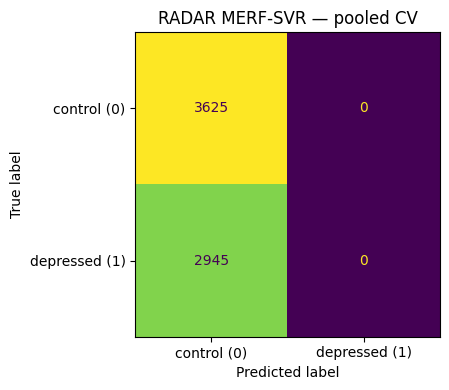

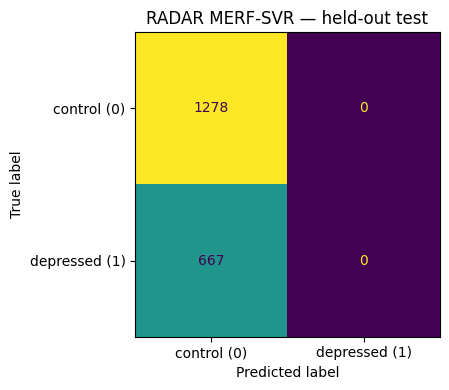


Pooled CV confusion matrix:
 [[3625    0]
 [2945    0]]

Held-out test confusion matrix:
 [[1278    0]
 [ 667    0]]

RADAR MERF-SVR SHAP summary (n=500):
  SHAP failed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVR(C=0.1)

RADAR MERF-SVR LIME (2 instances):


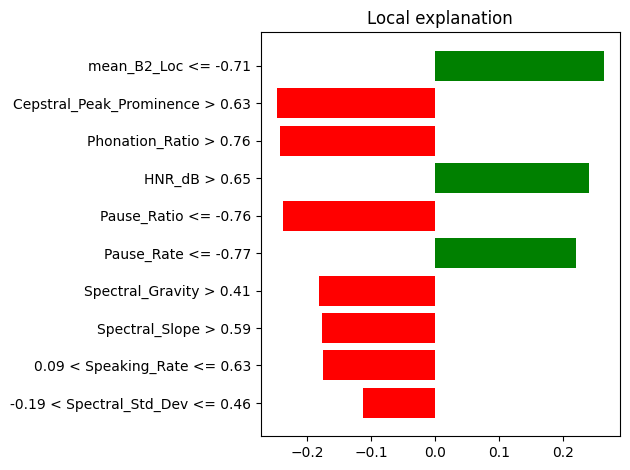

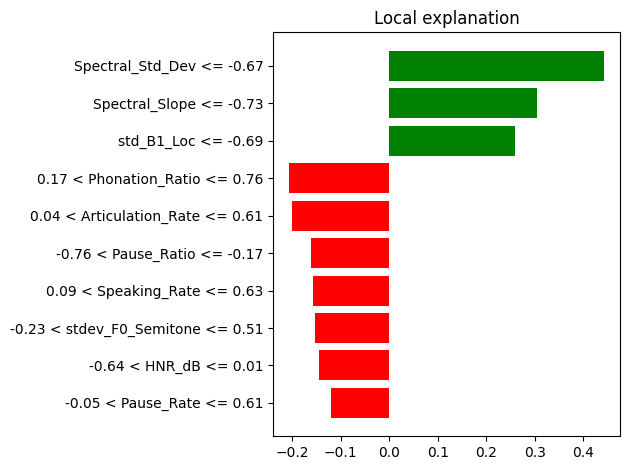


MODEL SECTION: Androids MERF-SVR

Train rows: 166 | Test rows: 43
Groups train: 85 | test: 22

Train/Test BDI balance:
      comparison  train_n  test_n  train_mean_bdi  test_mean_bdi  kruskal_H  \
0  train_vs_test      166      43       17.096386      20.883721   0.674244   

    p_value  
0  0.411576  


INFO     [merf.py:307] Training GLL is 1261.2887050386162 at iteration 1.
INFO     [merf.py:307] Training GLL is 1239.9900664049646 at iteration 2.
INFO     [merf.py:307] Training GLL is 1246.9202755553843 at iteration 3.


Best SVR params from GridSearchCV: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
BDI threshold for binary metrics (train midpoint): 25.50


INFO     [merf.py:307] Training GLL is 1251.185101914396 at iteration 4.
INFO     [merf.py:307] Training GLL is 1253.8713167914466 at iteration 5.
INFO     [merf.py:307] Training GLL is 1255.8092304710096 at iteration 6.
INFO     [merf.py:307] Training GLL is 1257.2943386869763 at iteration 7.
INFO     [merf.py:307] Training GLL is 1258.4376720294915 at iteration 8.
INFO     [merf.py:307] Training GLL is 1259.2929752335942 at iteration 9.
INFO     [merf.py:307] Training GLL is 1259.8994889955527 at iteration 10.
INFO     [merf.py:307] Training GLL is 1260.2917787079002 at iteration 11.
INFO     [merf.py:307] Training GLL is 1260.5030356503812 at iteration 12.
INFO     [merf.py:307] Training GLL is 1260.5628141674267 at iteration 13.
INFO     [merf.py:307] Training GLL is 1260.5006945087894 at iteration 14.
INFO     [merf.py:307] Training GLL is 1260.3392247350596 at iteration 15.
INFO     [merf.py:307] Training GLL is 1260.0995076892493 at iteration 16.
INFO     [merf.py:307] Training 

  Wilcoxon p fold 1: 0.005451865304515232


...

  Wilcoxon p fold 4: 0.7955069493632605


INFO     [merf.py:307] Training GLL is 1146.1655050641725 at iteration 3.
INFO     [merf.py:307] Training GLL is 1149.6094602819103 at iteration 4.
INFO     [merf.py:307] Training GLL is 1151.409459814085 at iteration 5.
INFO     [merf.py:307] Training GLL is 1152.5047308892226 at iteration 6.
INFO     [merf.py:307] Training GLL is 1153.2031052995042 at iteration 7.
INFO     [merf.py:307] Training GLL is 1153.6060020827847 at iteration 8.
INFO     [merf.py:307] Training GLL is 1153.7823672292764 at iteration 9.
INFO     [merf.py:307] Training GLL is 1153.7827146198981 at iteration 10.
INFO     [merf.py:307] Training GLL is 1153.6469108924694 at iteration 11.
INFO     [merf.py:307] Training GLL is 1153.415769409506 at iteration 12.
INFO     [merf.py:307] Training GLL is 1153.1155433777308 at iteration 13.
INFO     [merf.py:307] Training GLL is 1152.684677592684 at iteration 14.
INFO     [merf.py:307] Training GLL is 1152.1108375644985 at iteration 15.
INFO     [merf.py:307] Training GLL

  Wilcoxon p fold 5: 0.9358945410647527

CV fold results:
   fold        mae       rmse        r2  accuracy        f1   roc_auc  \
0     1   9.820105  13.143199  0.281602  0.588235  0.000000  0.742857   
1     2  12.525869  14.308292  0.049822  0.424242  0.000000  0.759398   
2     3  11.697320  14.126749 -0.363522  0.363636  0.000000  0.722222   
3     4  10.783391  13.864085 -0.102995  0.484848  0.000000  0.735294   
4     5  13.486186  17.697585 -0.095409  0.545455  0.210526  0.507353   

   wilcoxon_p_vs_train_mean_baseline  
0                           0.005452  
1                           0.195034  
2                           0.122090  
3                           0.795507  
4                           0.935895  

CV summary:
     subset  n_rows  n_depressed  n_control   mae_mean  rmse_mean   r2_mean  \
0  cv_train     166           88         78  11.662574  14.627982 -0.046101   

   accuracy_mean   f1_mean  roc_auc_mean  
0       0.481283  0.042105      0.693425  


INFO     [merf.py:307] Training GLL is 1449.1585654219566 at iteration 3.
INFO     [merf.py:307] Training GLL is 1450.0392867860617 at iteration 4.
INFO     [merf.py:307] Training GLL is 1449.458583880411 at iteration 5.
INFO     [merf.py:307] Training GLL is 1448.4598873255206 at iteration 6.
INFO     [merf.py:307] Training GLL is 1447.3458635202296 at iteration 7.
INFO     [merf.py:307] Training GLL is 1446.1320201048597 at iteration 8.
INFO     [merf.py:307] Training GLL is 1444.805292031693 at iteration 9.
INFO     [merf.py:307] Training GLL is 1443.4795085348098 at iteration 10.
INFO     [merf.py:307] Training GLL is 1442.115528354373 at iteration 11.
INFO     [merf.py:307] Training GLL is 1440.7480039333843 at iteration 12.
INFO     [merf.py:307] Training GLL is 1439.4041497975898 at iteration 13.
INFO     [merf.py:307] Training GLL is 1438.0827942472047 at iteration 14.
INFO     [merf.py:307] Training GLL is 1436.7809293864482 at iteration 15.
INFO     [merf.py:307] Training GLL


Held-out test results:
          subset  n_rows  n_depressed  n_control        mae       rmse  \
0  held_out_test      43           19         24  13.569636  17.706271   

        r2  accuracy   f1   roc_auc  bdi_threshold  
0 -0.01587   0.55814  0.0  0.776316           25.5  

Wilcoxon p (held-out): 0.054821915896162456

Androids MERF-SVR Gender results:
    group   n  n_depressed  n_control  accuracy   f1   roc_auc
0  female  35           15         20  0.571429  0.0  0.713333
1    male   8            4          4  0.500000  0.0  1.000000

Androids MERF-SVR Age group results:
    group   n  n_depressed  n_control  accuracy   f1  roc_auc
0  middle  25           13         12  0.480000  0.0  0.74359
1   older  14            4         10  0.714286  0.0  1.00000
2   young   4            2          2  0.500000  0.0  1.00000

Androids MERF-SVR Gender x age group results:
           group   n  n_depressed  n_control  accuracy   f1   roc_auc
0  middle female  23           13         10  0.4

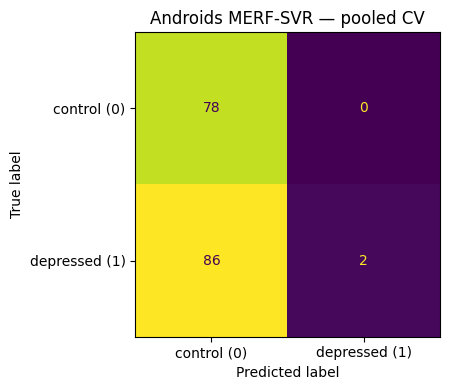

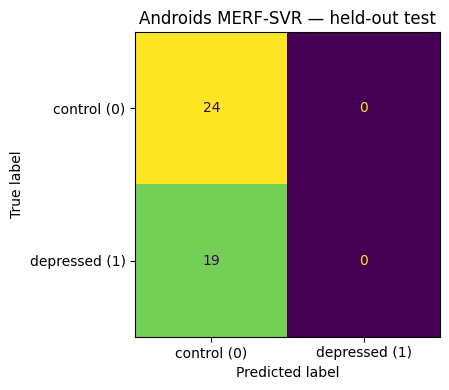


Pooled CV confusion matrix:
 [[78  0]
 [86  2]]

Held-out test confusion matrix:
 [[24  0]
 [19  0]]

Androids MERF-SVR SHAP summary (n=43):
  SHAP failed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVR(C=10, gamma=0.01)

Androids MERF-SVR LIME (2 instances):


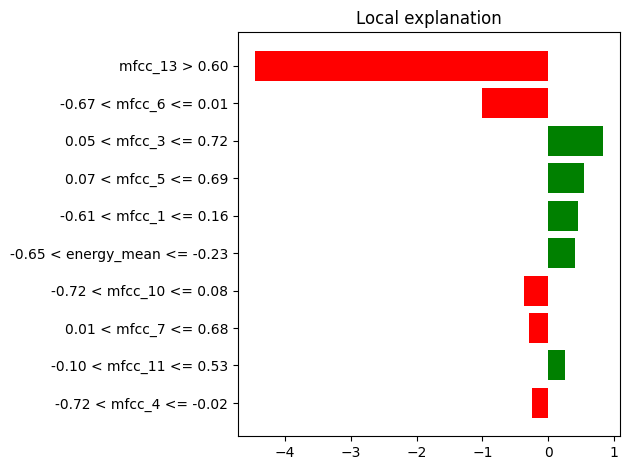

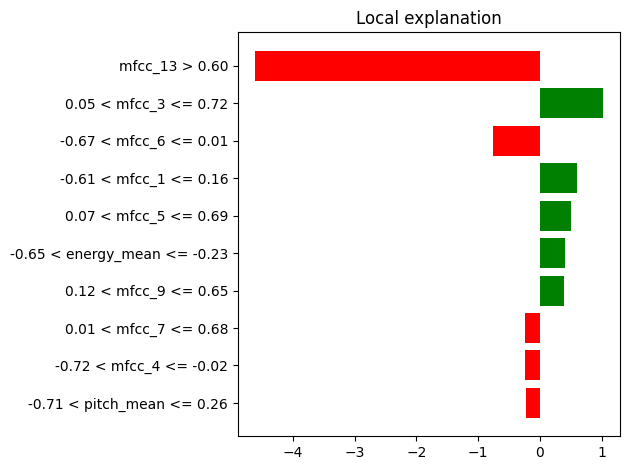

Excel workbook saved to: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\logs\merf_svr_results.xlsx

CSV exports (15 files) under: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\logs\merf_svr

Merged MERF results into: C:\Users\janku\Documents\KCL\Research Project\Research Project\results\logs\svm_results.xlsx


WindowsPath('C:/Users/janku/Documents/KCL/Research Project/Research Project/results/logs/merf_svr_results.xlsx')

In [45]:
def run_all(export_excel=True, export_csv=True, merge_into_svm_workbook=True):
    reset_results_store()
    run_merf_svr_radar()
    run_merf_svr_androids()
    if export_excel:
        export_results(export_csv=export_csv, merge_into_svm_workbook=merge_into_svm_workbook)

reset_results_store()
run_merf_svr_radar()
run_merf_svr_androids()
export_results(export_csv=True, merge_into_svm_workbook=True)

